> **Branch:** `feature/stage5-feature-engineering`  
> **Author:** Theertha  
> ⚠️ **Before running:** Make sure you have already run `stage00_dataset_generator.ipynb` in the same Colab session so that `/content/dataset` and all shared variables are available.


---
# STAGE 5 — Feature Engineering & Selection
**Author: Theertha**  
**Branch: feature/stage5-feature-engineering**

---

### Features extracted:
1. **HOG** — Histogram of Oriented Gradients (stroke orientation)
2. **Projection Profiles** — Horizontal & vertical pixel sums (shape descriptor)
3. **Run-Length Features** — Stroke structure encoding

In [23]:
# ============================================================
# STAGE 5 — FEATURE ENGINEERING & SELECTION
# Author: Theertha
# ============================================================

from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported")

✅ Libraries imported


In [24]:
def extract_hog_features(img_flat):
    """Extract HOG features from a flattened 32x32 image."""
    img = img_flat.reshape(32, 32)
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )
    return features

def extract_projection_profiles(img_flat):
    """Extract horizontal and vertical projection profiles."""
    img = img_flat.reshape(32, 32)
    horizontal = img.sum(axis=1)  # sum across columns → 32 values
    vertical   = img.sum(axis=0)  # sum across rows    → 32 values
    return np.concatenate([horizontal, vertical])  # 64 values

def extract_run_length_features(img_flat, max_runs=32):
    """Extract pixel run-length features (stroke structure)."""
    runs = []
    img = img_flat.reshape(32, 32)
    for row in img:
        run_len = 0
        in_run  = False
        for pixel in row:
            if pixel > 0:
                run_len += 1
                in_run = True
            else:
                if in_run:
                    runs.append(run_len)
                    run_len = 0
                    in_run = False
        if in_run:
            runs.append(run_len)

    # Pad or truncate to fixed size
    if len(runs) >= max_runs:
        runs = runs[:max_runs]
    else:
        runs = runs + [0] * (max_runs - len(runs))
    return np.array(runs)

print("✅ Feature extraction functions defined")

✅ Feature extraction functions defined


In [25]:
# Extract all features for all images
print("Extracting features... (this may take a minute)")

hog_features   = np.array([extract_hog_features(x) for x in X])
proj_features  = np.array([extract_projection_profiles(x) for x in X])
runl_features  = np.array([extract_run_length_features(x) for x in X])

# Concatenate all features
X_combined = np.concatenate([hog_features, proj_features, runl_features], axis=1)

print(f"\n✅ Features extracted!")
print(f"   HOG features:        {hog_features.shape[1]}")
print(f"   Projection profiles: {proj_features.shape[1]}")
print(f"   Run-length features: {runl_features.shape[1]}")
print(f"   Total features:      {X_combined.shape[1]}")
print(f"   Total samples:       {X_combined.shape[0]}")

Extracting features... (this may take a minute)

✅ Features extracted!
   HOG features:        1764
   Projection profiles: 64
   Run-length features: 32
   Total features:      1860
   Total samples:       3500


In [26]:
# Normalise features with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

print(f"✅ Features normalised with StandardScaler")
print(f"   Mean after scaling: {X_scaled.mean():.4f} (should be ~0)")
print(f"   Std after scaling:  {X_scaled.std():.4f} (should be ~1)")

✅ Features normalised with StandardScaler
   Mean after scaling: -0.0000 (should be ~0)
   Std after scaling:  0.9179 (should be ~1)


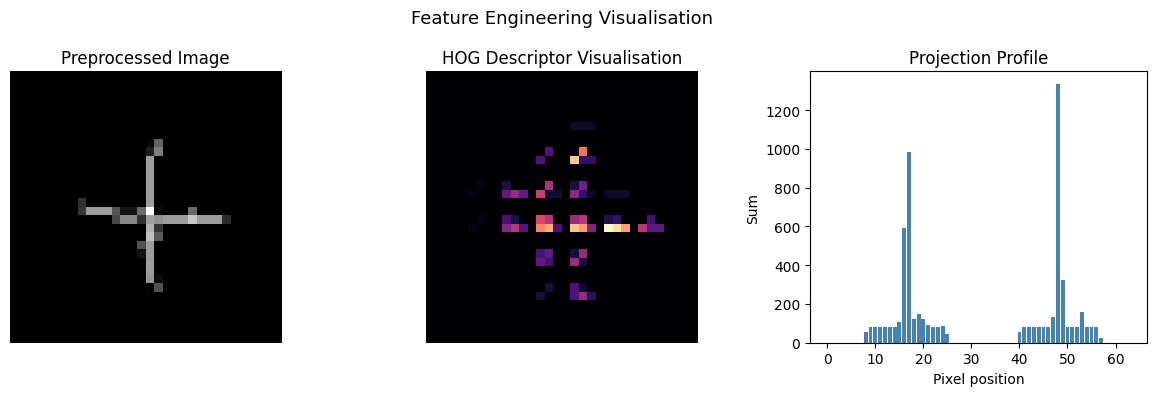

Stage 5 Complete ✅


In [27]:
# Visualise HOG descriptor on a sample image
from skimage.feature import hog

sample_img = X[0].reshape(32, 32)
_, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('Preprocessed Image')
axes[0].axis('off')

axes[1].imshow(hog_image, cmap='magma')
axes[1].set_title('HOG Descriptor Visualisation')
axes[1].axis('off')

axes[2].bar(range(len(proj_features[0])), proj_features[0], color='steelblue')
axes[2].set_title('Projection Profile')
axes[2].set_xlabel('Pixel position')
axes[2].set_ylabel('Sum')

plt.suptitle('Feature Engineering Visualisation', fontsize=13)
plt.tight_layout()
plt.savefig('feature_visualisation.png', dpi=150)
plt.show()
print("Stage 5 Complete ✅")